# Endterm exam

<b>Lim, Shedrick T.</b>
<br>Computer Engineering Technologist yarn

In [103]:
# imports and packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.power import TTestPower

In [ ]:
# load dataset
df = pd.read_csv(r"dataset/cities_air_quality_water_pollution.18-10-2021 (1).csv",
                 delimiter=",")
df

,City,"""Region""","""Country""","""AirQuality""","""WaterPollution"""
0,New York City,"""New York""","""United States of America""",46.816038,49.504950
1,"Washington, D.C.","""District of Columbia""","""United States of America""",66.129032,49.107143
2,San Francisco,"""California""","""United States of America""",60.514019,43.000000
3,Berlin,"""""","""Germany""",62.364130,28.612717
4,Los Angeles,"""California""","""United States of America""",36.621622,61.299435
...,...,...,...,...,...
3958,Yanbu,"""Medina Province""","""Saudi Arabia""",0.000000,50.000000
3959,Cordoba,"""Andalusia""","""Spain""",85.714286,8.333333
3960,Vic,"""Catalonia""","""Spain""",100.000000,0.000000
3961,Segovia,"""Castile and Leon""","""Spain""",100.000000,0.000000


In [105]:
# summary of dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3963 entries, 0 to 3962
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   City               3963 non-null   str    
 1    "Region"          3963 non-null   str    
 2    "Country"         3963 non-null   str    
 3    "AirQuality"      3963 non-null   float64
 4    "WaterPollution"  3963 non-null   float64
dtypes: float64(2), str(3)
memory usage: 298.5 KB


In [106]:
# summary of statistics
df.describe()

,"""AirQuality""","""WaterPollution"""
count,3963.000000,3963.000000
mean,62.253452,44.635372
std,30.944753,25.663910
min,0.000000,0.000000
25%,37.686567,25.000000
50%,69.444444,50.000000
75%,87.500000,57.719393
max,100.000000,100.000000


In [107]:
df.head()

,City,"""Region""","""Country""","""AirQuality""","""WaterPollution"""
0,New York City,"""New York""","""United States of America""",46.816038,49.504950
1,"Washington, D.C.","""District of Columbia""","""United States of America""",66.129032,49.107143
2,San Francisco,"""California""","""United States of America""",60.514019,43.000000
3,Berlin,"""""","""Germany""",62.364130,28.612717
4,Los Angeles,"""California""","""United States of America""",36.621622,61.299435


## Data Cleaning

In [108]:
df.columns = df.columns.str.strip().str.replace('"', '')



for col in df.select_dtypes(include=['object']).columns:

    # First, convert to string

    df[col] = df[col].astype(str)

    # Remove leading/trailing spaces and literal double quotes

    df[col] = df[col].str.strip().str.replace('"', '', regex=False)

    # Replace empty strings with 'unavailable'

    # Also handle cases where it might just be the word 'nan' from pd.read_csv

    df[col] = df[col].replace({'': 'Unavailable', 'nan': 'Unavailable'})


df



C:\Users\ASUS\AppData\Local\Temp\ipykernel_59252\2982698494.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include=['object']).columns:


,City,Region,Country,AirQuality,WaterPollution
0,New York City,New York,United States of America,46.816038,49.504950
1,"Washington, D.C.",District of Columbia,United States of America,66.129032,49.107143
2,San Francisco,California,United States of America,60.514019,43.000000
3,Berlin,Unavailable,Germany,62.364130,28.612717
4,Los Angeles,California,United States of America,36.621622,61.299435
...,...,...,...,...,...
3958,Yanbu,Medina Province,Saudi Arabia,0.000000,50.000000
3959,Cordoba,Andalusia,Spain,85.714286,8.333333
3960,Vic,Catalonia,Spain,100.000000,0.000000
3961,Segovia,Castile and Leon,Spain,100.000000,0.000000


# Outliers 

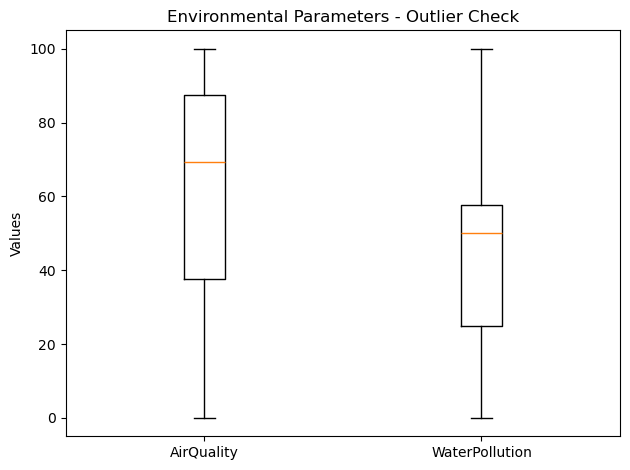

In [109]:
cols = [
    'AirQuality', 
    'WaterPollution'
]
plt.boxplot(df[cols], tick_labels=cols)


# Title and Labels
plt.title('Environmental Parameters - Outlier Check')
plt.ylabel('Values')

plt.xticks(rotation=0) 

# Ensure nothing is cut off
plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_59252\260169040.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[col], labels=[col])


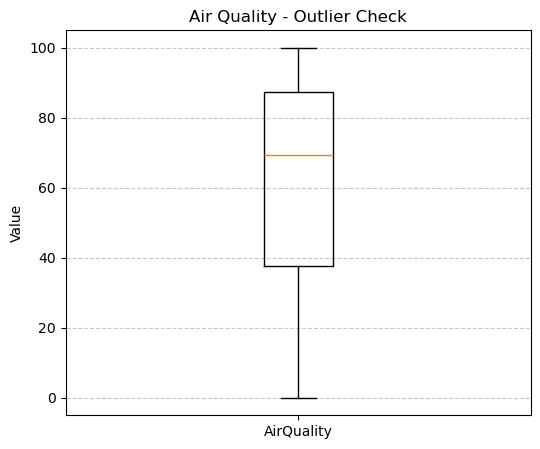

In [ ]:
# air quality
# removing 3-sigma outliers
z_wind = stats.zscore(df['AirQuality'])
wind_outliers = (z_wind<-3)|(z_wind>3)
df = df[~wind_outliers]

plt.boxplot(df['AirQuality'],tick_labels=['Air Quality'])
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_59252\2008067258.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(df[col], labels=[col])


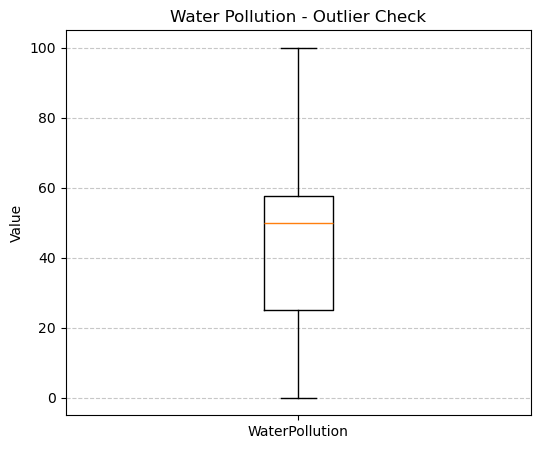

In [ ]:
# water pollution
# removing 3-sigma outliers
z_water = stats.zscore(df['WaterPollution'])
water_outliers = (z_water<-3)|(z_water>3)
df = df[~water_outliers]

plt.boxplot(df['WaterPollution'],tick_labels=['Water Pollution'])
plt.show()

In [112]:
# storage of means
numeric_cols = df.select_dtypes(include=[np.number]).columns
means_data = {c: [] for c in numeric_cols}

In [113]:
np.random.seed(42)

# sampling means
for _ in range(50): # 50 times
    for c in numeric_cols:
        sample = np.random.choice(df[c], size=30, replace=True)
        means_data[c].append(np.mean(sample))



In [114]:
df_means = pd.DataFrame(means_data)
df_means

,AirQuality,WaterPollution
0,74.129357,44.288064
1,68.554787,52.712314
2,61.700650,47.736035
3,66.699355,42.787698
4,60.471541,44.464602
5,68.106286,47.678613
6,74.316381,41.350087
7,61.744096,49.494161
8,59.604107,41.586514
9,63.345545,47.878295


In [115]:
# Save it just like in your reference
df_means.to_csv('sampling_means_air_water.csv', index=False)
df_means.head()

,AirQuality,WaterPollution
0,74.129357,44.288064
1,68.554787,52.712314
2,61.700650,47.736035
3,66.699355,42.787698
4,60.471541,44.464602


## Normality test

In [116]:
df = pd.read_csv(r"sampling_means_air_water.csv",
                 delimiter=",")
df.head()

,AirQuality,WaterPollution
0,74.129357,44.288064
1,68.554787,52.712314
2,61.700650,47.736035
3,66.699355,42.787698
4,60.471541,44.464602


In [117]:
# shapiro-wilk normality test
print("Air Quality:")
w_stat, p_value = stats.shapiro(df_means['AirQuality'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")
    
print("\nWater Pollution:")
w_stat, p_value = stats.shapiro(df_means['WaterPollution'])

print(f"w_stat: {w_stat:.4f}")
print(f"P-value: {p_value:.4f}")

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("Non-normal data")
else:
    # fail to reject null hypothesis
    print("Normal data")

Air Quality:
w_stat: 0.9820
P-value: 0.6391
Normal data

Water Pollution:
w_stat: 0.9733
P-value: 0.3141
Normal data


## 2 Sample T-test

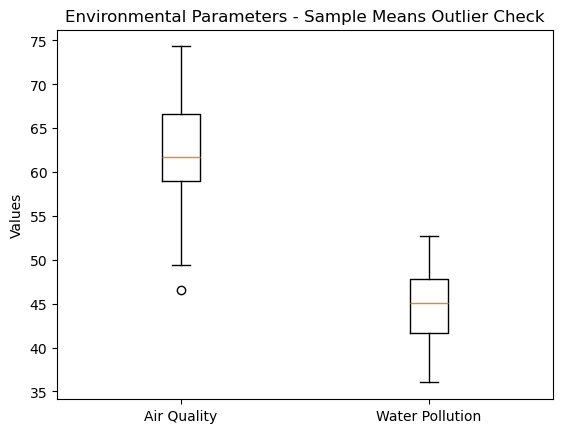

In [118]:
# check for outliers
plt.boxplot(df_means[['AirQuality','WaterPollution']],tick_labels=['Air Quality','Water Pollution'])
plt.title("Environmental Parameters - Sample Means Outlier Check")
plt.ylabel('Values')
plt.show()

In [119]:
"""
F-Test for equality of variances
--------------------------------
Ho: var_airqual = var_waterpol
Ha: var_airqual != var_waterpol
"""

var_airqual = df_means['AirQuality'].var(ddof=1)
var_waterpol = df_means['WaterPollution'].var(ddof=1)

# F-statistic
if var_airqual > var_waterpol:
    f_stat = var_airqual/var_waterpol
else:
    f_stat = var_waterpol/var_airqual

print(f'f_stat = {f_stat:.4f}')

# Degrees of Freedom
dof_airqual = df_means['AirQuality'].count()-1
dof_waterpol = df_means['WaterPollution'].count()-1

# probability value
p_value = 1 - stats.f.cdf(f_stat, dof_airqual, dof_waterpol)
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("unequal variances")
else:
    # fail to reject null hypothesis
    print("equal variances")

f_stat = 1.9811
p_value = 0.0092
unequal variances


In [120]:
"""
2- Sample T-Test for Independent Samples
----------------------------------------
Ho: Air Quality <= Water Pollution
Ha: Air Quality > Water Pollution
"""

t_stat, p_value = stats.ttest_ind(df_means['AirQuality'],df_means['WaterPollution'],
                                  alternative='greater',
                                  equal_var=True)

print(f't_stat = {t_stat:.4f}')
print(f'p_value = {p_value:.4f}')

# verdict
alpha = 0.05
if p_value < alpha:
    # reject null hypothesis
    print("There is a significant difference; Air Quality is higher than Water Pollution.")
else:
    # fail to reject null hypothesis
    print("There is no significant difference between Air Quality and Water Pollution.")

t_stat = 16.1790
p_value = 0.0000
There is a significant difference; Air Quality is higher than Water Pollution.


In [121]:
    """
    left-tailed test
    ------------------
    Ho: u_airqual = u_waterpol
    Ha: u_airqual > u_waterpol
    """
        
    # cohen's d
    airq_mean = df_means['AirQuality'].mean()
    waterpol_mean = df_means['WaterPollution'].mean()
    airq_std = df_means['AirQuality'].std(ddof=1)

    d = abs((airq_mean - waterpol_mean)/airq_std)

    print(f"Cohen's d: {d:.4f}")

    # power of a test
    power = TTestPower().power(
        effect_size = -d, # difference must be negative for alternative='smaller'
        nobs = df_means['AirQuality'].count(),
        alpha = 0.05,
        alternative = "smaller"
    )

    print(f"Power of the test: {power*100:.2f}%")

Cohen's d: 2.8067
Power of the test: 100.00%
